# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    infer_cv_block_size_from_gaps,
    create_block_splits,
    plot_cv_splits,
    rfe_selection
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FCH4'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_ID = True
ADD_TRT = True
ADD_CANOPY = False

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"83.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 83.1.1_GapFillingDataset.parquet (0.343 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Using data from 2023-11-08 to 2024-08-21

Target column: FCH4_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FCH4_L3.3_CUT_16_QCF,FCH4_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_84_QCF,FCH4_L3.3_CUT_16_QCF0,FCH4_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FCH4_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,3.267421,-0.959339,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,-3.231648,B,certain,1.0,2.89451,0.0,0.0,5.333333,...,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,0.088359,0.194877,1825
2023-11-08 00:45:00,3.162966,-0.814196,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,2.16145,0.0,0.0,5.966667,...,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,30.0,22.0,0.088452,0.195270,1826
2023-11-08 01:15:00,2.843573,-0.503249,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.59022,0.0,0.0,5.833333,...,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,30.0,22.0,0.088546,0.195664,1827
2023-11-08 01:45:00,3.057733,-0.715197,6.746138,6.746138,6.746138,NaN,NaN,NaN,B,certain,1.0,3.18448,0.0,0.0,5.866667,...,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,30.0,22.0,0.088639,0.196058,1828
2023-11-08 02:15:00,2.823540,-0.487326,3.168362,3.168362,3.168362,3.168362,3.168362,3.168362,B,certain,1.0,1.69820,0.0,0.0,5.766667,...,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,0.088733,0.196452,1829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-21 21:45:00,4.180460,0.419748,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.81862,0.0,0.0,13.353333,...,-1.707135,0.024579,-0.259299,-0.314632,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,15644
2024-08-21 22:15:00,4.675844,-0.131424,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.40756,0.0,0.0,12.743333,...,-1.744187,0.026603,-0.248552,-0.346094,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,15645
2024-08-21 22:45:00,4.605323,-0.096441,-6.892062,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,7.90532,0.0,0.0,12.346667,...,-1.720830,0.028865,-0.235925,-0.360680,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,0.000000,0.000000,15646


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

# Remove teatment variable if ADD_TRT==False
if ADD_TRT==False:
    data.drop(columns='trt', inplace=True)
    print('\nRemoved the treatment variable (trt)')
else:
    print('\nKeeping the treatment variable (trt)')

# Remove canopy variables if ADD_CANOPY==False
if ADD_CANOPY==False:
    prefix = ('LAI', 'can_height')
    to_drop = [c for c in data.columns if c.startswith(prefix)]
    data.drop(columns=to_drop, inplace=True)
    print(f"\nDropped {len(to_drop)} canopy columns: {to_drop}")

# Drop variables related to specific parcels
to_drop = [c for c in data.columns if 'parcel' in c]
data.drop(columns=to_drop, inplace=True)
print(f"\nDropped {len(to_drop)} parcel-specific columns: {to_drop}")

# keep numeric only (feature selection models require numeric)
data = data.select_dtypes(include=[np.number]).copy()

# Remove any flux variable with TARGET_FLUX except for the target itself
to_drop = [c for c in data.columns if (TARGET_FLUX in c and c != TARGET)]
data.drop(columns=to_drop, inplace=True)

# Remove feature columns with too many missing values where target is not missing
drop_missing = [
    c for c in data.columns
    if c != TARGET and data[c].isna().mean() > 0.05
]
data.drop(columns=drop_missing, inplace=True)
print(f"Dropped {len(drop_missing)} high-missing features (>5% NA) where target is not missing: {drop_missing}")

# Build complete-case training set
feature_cols = [c for c in data.columns if c != TARGET]
train_mask = data[TARGET].notna() & data[feature_cols].notna().all(axis=1)
df_train = data.loc[train_mask, feature_cols + [TARGET]].copy()
print(f"Training rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[feature_cols]
y = df_train[TARGET].astype(float)

df_train

Filtered parcel_certainty=='certain': 1345/1540 rows kept

Keeping the treatment variable (trt)

Dropped 6 canopy columns: ['LAI_parcelA', 'LAI_parcelB', 'can_height_parcelA', 'can_height_parcelB', 'LAI', 'can_height']

Dropped 18 parcel-specific columns: ['parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'timesince_fert_min_parcelA', 'timesince_fert_min_parcelB', 'timesince_fert_org_parcelA', 'timesince_fert_org_parcelB']
Dropped 0 high-missing features (>5% NA) where target is not missing: []
Training rows (complete-case): 1345/1345


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,trt,SW_IN_POT,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,crop,timesince_soil_preparation,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,id,FCH4_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,3.267421,-0.959339,1.0,0.0000,0.0,5.333333,12,6.902486,9.815343,10.908412,45.779250,55.128997,42.768103,1.0,21.0,...,-0.188894,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,30.0,22.0,1825,-3.231648
2023-11-08 02:15:00,2.823540,-0.487326,1.0,0.0000,0.0,5.766667,16,7.089032,9.802778,11.114241,45.888163,55.228593,42.971042,1.0,21.0,...,-0.028905,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,30.0,22.0,1829,3.168362
2023-11-08 02:45:00,2.679557,-0.349672,1.0,0.0000,0.0,5.666667,17,7.110031,9.717873,10.808778,45.900727,55.221686,43.013259,1.0,21.0,...,-0.018750,0.245680,0.083496,0.088045,0.647077,0.0,0.0,2.157967,0.971280,29.0,22.0,30.0,22.0,1830,8.004995
2023-11-08 03:15:00,2.681954,-0.369115,1.0,0.0000,0.0,5.400000,18,7.258470,9.776045,10.794777,45.847515,55.221308,43.030472,1.0,21.0,...,-0.069987,0.059082,0.121729,0.069218,0.542432,0.0,0.0,2.152567,0.968238,29.0,22.0,30.0,22.0,1831,-3.270484
2023-11-08 05:15:00,2.427758,-0.138238,1.0,0.0000,0.0,5.033333,22,6.612354,9.996383,10.709149,45.973385,55.272922,43.440474,1.0,21.0,...,0.122429,0.018764,0.876177,0.054961,0.979191,0.0,0.0,2.131102,0.956176,29.0,22.0,30.0,22.0,1835,-12.813660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-20 08:15:00,1.855749,2.915242,0.0,654.9330,0.0,16.366667,52,19.424443,20.142223,20.040740,35.980185,47.381055,43.021562,2.0,15.0,...,-0.714479,-2.097743,-0.031954,0.008492,0.263486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,15569,-19.752590
2024-08-20 13:45:00,1.879419,3.299258,0.0,1030.1400,0.0,21.006667,63,22.768148,20.760370,19.956666,35.665226,46.977597,42.913925,2.0,16.0,...,-0.740482,-1.721083,-0.117190,-0.138414,0.034627,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,15580,-6.165051
2024-08-21 00:15:00,4.887125,0.202818,1.0,0.0000,0.0,19.920000,84,20.641112,21.465926,20.640001,33.542140,46.324699,42.904943,2.0,16.0,...,-0.733296,-1.507235,0.153967,-0.062227,-0.147486,0.0,0.0,0.000000,0.000000,0.0,30.0,30.0,30.0,15601,45.188613


# IMBALANCE HANDLING

## UNDER SAMPLING

In [5]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [6]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")


Log transform not applied.


# CROSS-VAL SPLITS


Using block size of 4 time steps for CV splits.

Requested split=0.10; n_folds=10; achieved test fractions ~ 0.098–0.101


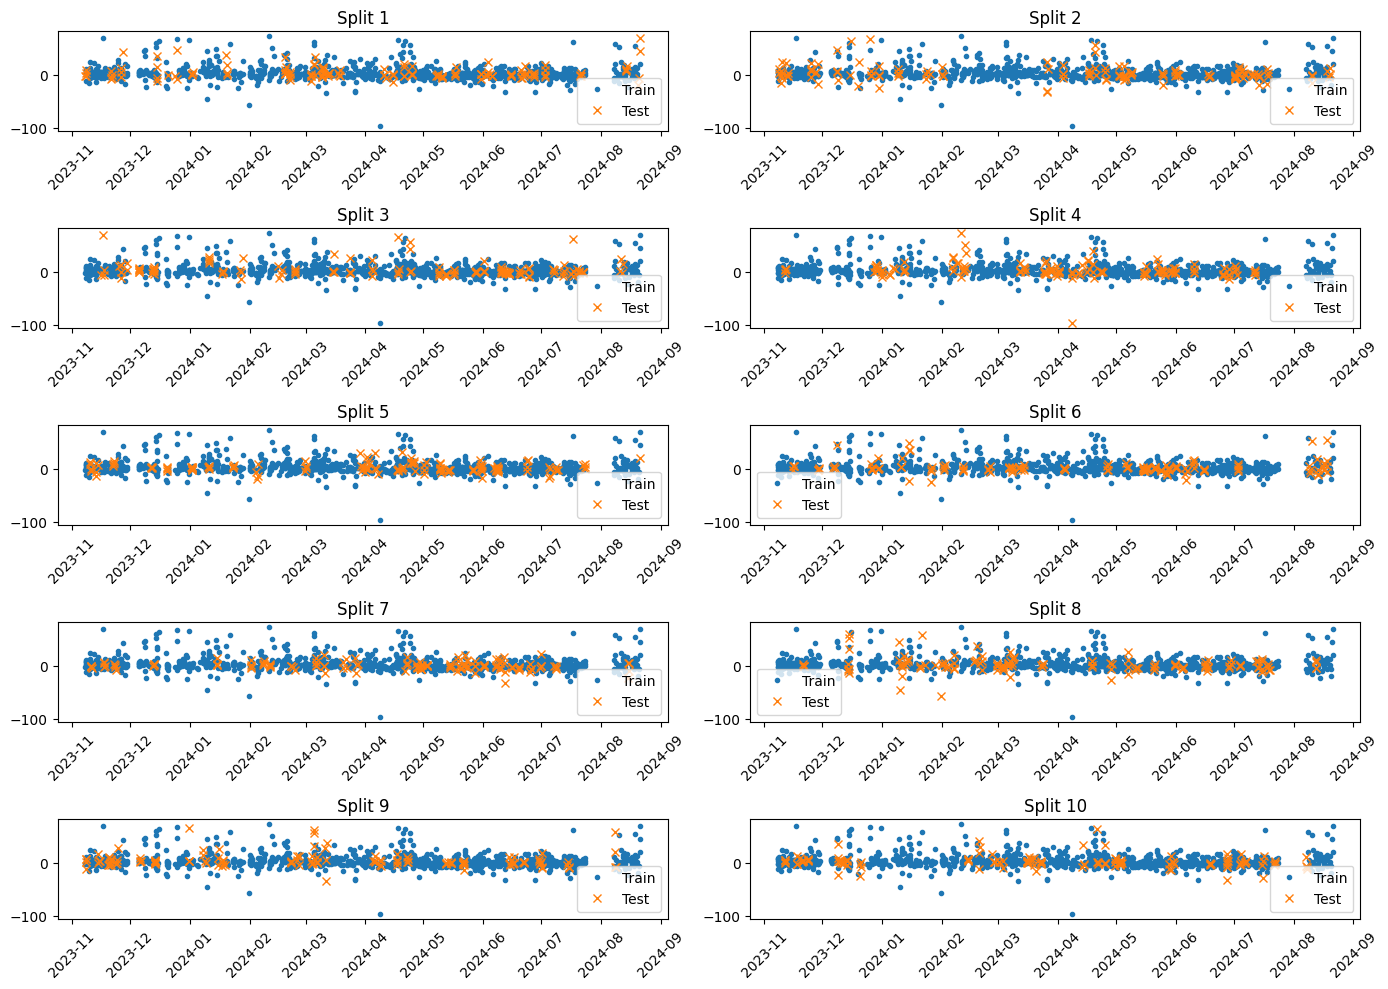

In [7]:
# Time-block cross-validation splits
# Block size is inferred from gaps in the target variable
block_size = infer_cv_block_size_from_gaps(data_main[TARGET], quantile=0.9, fallback=6)
print(f"\nUsing block size of {block_size} time steps for CV splits.\n")
split_frac = 1.0 / float(N_FOLDS)
splits = create_block_splits(
    X,
    split=split_frac,
    block_size=block_size,
    random_state=42,
    shuffle_blocks=True,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# FEATURE SELECTION

In [8]:
# Model factory
def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif MODEL_TYPE == "XGBoost":
        return XGBRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    else:
        raise ValueError("MODEL_TYPE must be 'RandomForest' or 'XGBoost'")

model_factory()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

Iter 1: kept=154 removed=['timesince_harvest', 'timesince_fert_org', 'ts_0.15_gfXG_lag3h_roll6hmean', 'prec_lag9h', 'prec_lag3h_roll6hsum', 'ts_0.3_gfXG_roll6hmean', 'NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost', 'n_decay_logistic', 'prec_lag9h_roll3hsum', 'prec_roll3hsum'] RMSE_oof=12.7357 R2_oof=-0.0673
Iter 2: kept=144 removed=['prec_lag3h', 'wfps_0.05_gfXG_roll6hmean', 'wfps_0.05_gfXG_lag3h_roll3hmean', 'prec_lag6h_roll3hsum', 'prec_lag3h_roll9hsum', 'SW_IN_POT', 'n_decay_lognormal', 'prec_lag6h', 'n_decay_exponential', 'ts_0.05_gfXG_lag9h'] RMSE_oof=12.8895 R2_oof=-0.0933
Iter 3: kept=134 removed=['timesince_sowing', 'crop', 'ts_0.15_gfXG_lag6h_roll9hmean', 'ts_0.05_gfXG_lag3h_roll6hmean', 'wfps_0.05_gfXG_lag9h_roll6hmean', 'ts_0.3_gfXG', 'wfps_0.15_gfXG_lag3h', 'ts_0.15_gfXG_lag9h_roll9hmean', 'prec_roll9hsum', 'prec_lag6h_roll9hsum'] RMSE_oof=12.9422 R2_oof=-0.1022
Iter 4: kept=124 removed=['prec_lag6h_roll6hsum', 'wfps_0.3_gfXG_lag9h_roll6hmean', 'wfps_0.05_gfXG_lag3h_roll6hmean', 

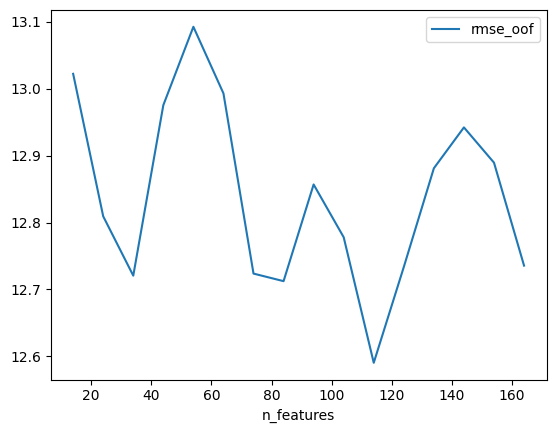

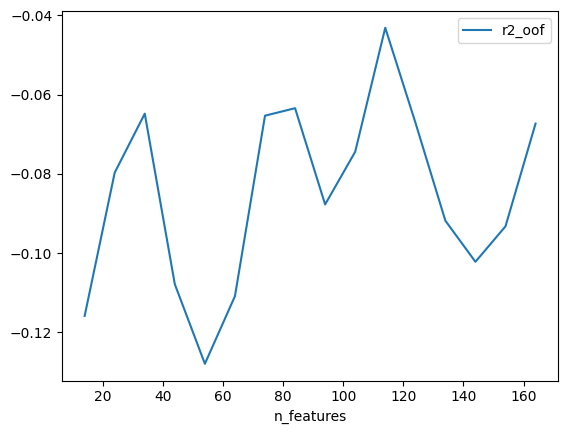

In [9]:
best_feats, ranking, hist = rfe_selection(
    X, y, splits,
    model_factory=model_factory,
    inv_y=inv_fn if LOG_TRANSFORM else None,
    step=10,           # try 5 or 10 if it’s slow
    min_features=10,
    verbose=True,
    score_mode='composite',  # 'rmse' or 'composite',
    w_penalty = 0.001
)

# optional plot in notebook
hist.plot(x="n_features", y="rmse_oof");
hist.plot(x="n_features", y="r2_oof");

print(f"\nBest features selected:\n{best_feats}")
print(f"\nFeature ranking:\n{ranking}")

# EXPORT 

In [10]:
filename = f"best_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in best_feats:
        f.write(f"{item}\n")
print("Wrote:", filename)

filename = f"ranked_features_{TARGET_FLUX}_{MODEL_TYPE}.txt"
with open(filename, "w") as f:
    for item in ranking:
        f.write(f"{item}\n")
print("Wrote:", filename)


Wrote: best_features_FCH4_XGBoost.txt
Wrote: ranked_features_FCH4_XGBoost.txt


# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-02-24 15:03:59
